In [223]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance, gaussian_kde 
import scipy.stats as stats
from scipy.spatial.distance import jensenshannon
import statsmodels.formula.api as smf
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, r2_score


In [212]:
master_df = pd.read_csv('master_df_final.csv')
questions = master_df['Question'].unique()
master_df = master_df[master_df['BeforeNumber'].between(0, 10) & master_df['AfterNumber'].between(0, 10)]
master_df["llm_avg"] = master_df[[f"run_{seed}" for seed in range(0,10)]].mean(axis=1).round(0).clip(0,10)
print(master_df.columns)
print(master_df.shape)

Index(['ID', 'Question', 'QuestionText', 'Topic', 'ValidResponse',
       'BeforeNumber', 'BeforeResponse', 'AfterNumber', 'AfterResponse',
       'GROUP', 'RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER',
       'AGE', 'run_0', 'run_1', 'run_2', 'run_3', 'run_4', 'run_5', 'run_6',
       'run_7', 'run_8', 'run_9', 'llm_avg'],
      dtype='object')
(23094, 27)


In [213]:
# checking AI1R statements
#master_df = pd.read_csv('clean_data/question_level_master_dataset.csv')
demrep = master_df[(master_df['PARTYBEFORE']=='Democrat') | (master_df['PARTYBEFORE']=='Republican')]
extreme_data = demrep.groupby(['Question','PARTYBEFORE','BeforeNumber'])['ID'].count().reset_index()
extreme_data = extreme_data.rename(columns={'ID':'Count'})
extreme_data.head()

# Criterion A:  At least 15% of respondents identifying with each party (Democrats AND Republicans) selected
# the most extreme position (0 or 10 on a 0-10 scale), with these extremes positioned at opposite poles.
extremeQuestionsA = []
for question in questions:
    extremeQuestion = {}
    for party in ['Democrat', 'Republican']:
        subset = extreme_data[(extreme_data['Question']==question) & (extreme_data['PARTYBEFORE']==party)]
        total = subset['Count'].sum()
        prop0 = subset[subset['BeforeNumber'] == 0]['Count'].sum() / total
        prop10 = subset[subset['BeforeNumber'] == 10]['Count'].sum() / total
        left = subset[subset['BeforeNumber'] < 5]['Count'].sum()
        right = subset[subset['BeforeNumber'] > 5]['Count'].sum()
        if prop0 >= 0.15 and left > right:
            extremeQuestion[party] = 0
        elif prop10 >= 0.15 and right > left:
            extremeQuestion[party] = 10
    # assuming only one side can be extreme per party
        
    if len(extremeQuestion) == 2 and extremeQuestion['Democrat'] != extremeQuestion['Republican']:
        extremeQuestionsA.append(question)

print(f"Number of extreme questions: {len(extremeQuestionsA)}")

Number of extreme questions: 27


In [214]:
extreme_data = demrep.groupby(['Question','PARTYBEFORE','AfterNumber'])['ID'].count().reset_index()
extreme_data = extreme_data.rename(columns={'ID':'Count'})
extreme_data.head()

# Criterion A:  At least 15% of respondents identifying with each party (Democrats AND Republicans) selected
# the most extreme position (0 or 10 on a 0-10 scale), with these extremes positioned at opposite poles.
extremeQuestionsA = []
for question in questions:
    extremeQuestion = {}
    for party in ['Democrat', 'Republican']:
        subset = extreme_data[(extreme_data['Question']==question) & (extreme_data['PARTYBEFORE']==party)]
        total = subset['Count'].sum()
        prop0 = subset[subset['AfterNumber'] == 0]['Count'].sum() / total
        prop10 = subset[subset['AfterNumber'] == 10]['Count'].sum() / total
        left = subset[subset['AfterNumber'] < 5]['Count'].sum()
        right = subset[subset['AfterNumber'] > 5]['Count'].sum()
        if prop0 >= 0.15 and left > right:
            extremeQuestion[party] = 0
        elif prop10 >= 0.15 and right > left:
            extremeQuestion[party] = 10
    # assuming only one side can be extreme per party
        
    if len(extremeQuestion) == 2 and extremeQuestion['Democrat'] != extremeQuestion['Republican']:
        extremeQuestionsA.append(question)

print(f"Number of extreme questions: {len(extremeQuestionsA)}")

Number of extreme questions: 11


In [215]:
extreme_data = demrep.groupby(['Question','PARTYBEFORE','llm_avg'])['ID'].count().reset_index()
extreme_data = extreme_data.rename(columns={'ID':'Count'})
extreme_data.head()

# Criterion A:  At least 15% of respondents identifying with each party (Democrats AND Republicans) selected
# the most extreme position (0 or 10 on a 0-10 scale), with these extremes positioned at opposite poles.
extremeQuestionsA = []
for question in questions:
    extremeQuestion = {}
    for party in ['Democrat', 'Republican']:
        subset = extreme_data[(extreme_data['Question']==question) & (extreme_data['PARTYBEFORE']==party)]
        total = subset['Count'].sum()
        prop0 = subset[subset['llm_avg'] == 0]['Count'].sum() / total
        prop10 = subset[subset['llm_avg'] == 10]['Count'].sum() / total
        left = subset[subset['llm_avg'] < 5]['Count'].sum()
        right = subset[subset['llm_avg'] > 5]['Count'].sum()
        if prop0 >= 0.15 and left > right:
            extremeQuestion[party] = 0
        elif prop10 >= 0.15 and right > left:
            extremeQuestion[party] = 10
    # assuming only one side can be extreme per party
        
    if len(extremeQuestion) == 2 and extremeQuestion['Democrat'] != extremeQuestion['Republican']:
        extremeQuestionsA.append(question)

print(f"Number of extreme questions: {len(extremeQuestionsA)}")

Number of extreme questions: 5


In [154]:
master_df['llm_avg_rounded'] = master_df['llm_avg'].round(0).clip(0,10)

In [216]:
print(stats.wilcoxon(master_df['AfterNumber'], master_df['llm_avg']))
print(stats.wilcoxon(master_df['BeforeNumber'], master_df['llm_avg']))
print(stats.wilcoxon(master_df['AfterNumber'], master_df['BeforeNumber']))

WilcoxonResult(statistic=np.float64(60404400.5), pvalue=np.float64(3.446934717190165e-70))
WilcoxonResult(statistic=np.float64(25646020.5), pvalue=np.float64(0.0))
WilcoxonResult(statistic=np.float64(59567874.5), pvalue=np.float64(0.27388746079304405))


###TRAINING ON LLM ERROR

Text(0, 0.5, 'Wasserstein Distance between LLM and Human After Responses')

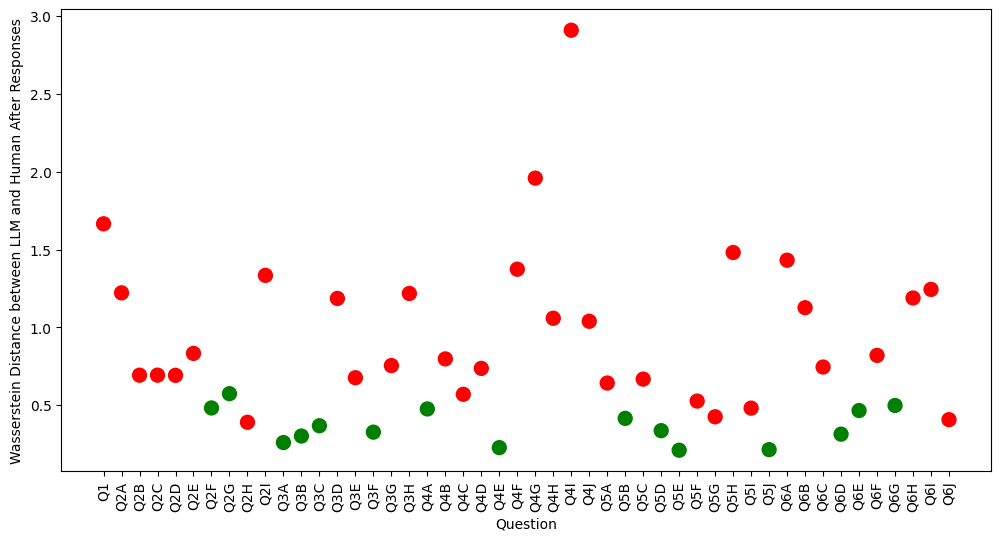

In [220]:
results = []
for question in questions:
    q_df = master_df[master_df['Question'] == question]
    human  = q_df['AfterNumber']

    llm = q_df[f'llm_avg']

    ks_stat, ks_pval = ks_2samp(human, llm)
    w_dist = wasserstein_distance(human, llm)
    # choose shared bins, e.g. 0,1,2,...,10
    bins = np.arange(0, 11)  # or np.arange(0, 11+1) if using np.histogram

    # histograms -> counts per bin
    h_counts, _ = np.histogram(human, bins=bins, density=False)
    l_counts, _ = np.histogram(llm, bins=bins, density=False)

    # convert to probabilities
    p_h = h_counts / h_counts.sum()
    p_l = l_counts / l_counts.sum()

    js = jensenshannon(p_h, p_l)

    wc = stats.wilcoxon(human, llm)
    
    results.append({
        'question': question,
        'human_shift': human.mean(),
        'llm_mean_shift': llm.mean(),
        'ks_D': ks_stat,
        'ks_p': ks_pval,
        'wasserstein': w_dist,
        'js_mean': js,
        'wilcoxon_stat': wc.statistic,
        'wilcoxon_p': wc.pvalue
        
    })
results_df = pd.DataFrame(results)
# get significant questions
results_df['no_sig_diff'] = results_df['wilcoxon_p'] > 0.05
plt.figure(figsize=(12, 6))
plt.scatter(results_df['question'], results_df['wasserstein'], s=100, c=results_df['no_sig_diff'].map({True: 'green', False: 'red'}))
plt.xticks(rotation=90)
plt.xlabel('Question')
plt.ylabel('Wasserstein Distance between LLM and Human After Responses')

In [221]:
# join results to master df to get topics
master_with_results = results_df.merge(master_df, left_on='question', right_on='Question', how='left')
master_with_results[['Question','Topic','no_sig_diff']].drop_duplicates().groupby(['Topic','no_sig_diff']).count()

Question
Topic           no_sig_diff          
Climate Change  False               4
                True                4
Democracy       False               1
Global Position False               7
                True                3
Healthcare      False               6
                True                4
Immigration     False               7
                True                2
Taxes           False               8
                True                2

In [222]:
# print out questions with no significant difference
no_sig_questions = results_df[results_df['no_sig_diff'] == True]['question'].tolist()
print(no_sig_questions)

['Q2F', 'Q2G', 'Q3A', 'Q3B', 'Q3C', 'Q3F', 'Q4A', 'Q4E', 'Q5B', 'Q5D', 'Q5E', 'Q5J', 'Q6D', 'Q6E', 'Q6G']


In [202]:
master_df['llm_avg_raw'] = master_df[[f"run_{seed}" for seed in range(0,10)]].mean(axis=1)


corrected_list = []
summary_results = {}
formula = "shift ~ C(RACE) + C(AGEBRACKET) + C(EDUCATION) + C(PARTYBEFORE) + C(GENDER)"

for question in questions:
    qdf = master_df[master_df['Question'] == question].copy()
    qdf['shift'] = qdf['AfterNumber'] - qdf['llm_avg_raw']
    
    # --- CROSS-VALIDATION (The "Evidence") ---
    # Split into 10 folds (4 groups each for 40 groups)
    gkf = GroupKFold(n_splits=10)
    cv_maes = []
    cv_baselines = []
    
    for train_idx, test_idx in gkf.split(qdf, qdf['shift'], groups=qdf['GROUP']):
        train_cv = qdf.iloc[train_idx]
        test_cv = qdf.iloc[test_idx]
        
        # Fit on training groups, predict for the 4 unseen groups
        cv_model = smf.mixedlm(formula, train_cv, groups=train_cv["GROUP"]).fit()
        cv_shift_preds = cv_model.predict(test_cv)
        
        # Round to original scale
        y_true = test_cv['AfterNumber']
        y_pred = (cv_shift_preds + test_cv['llm_avg_raw']).round().clip(0,10)
        baseline = test_cv['llm_avg_raw'].round().clip(0,10)
        
        cv_maes.append(mean_absolute_error(y_true, y_pred))
        cv_baselines.append(mean_absolute_error(y_true, baseline))

    # --- PRODUCTION (The "Correction") ---
    # Fit on all 40 groups to get the best correction for your current data
    final_model = smf.mixedlm(formula, qdf, groups=qdf["GROUP"]).fit()
    
    # We use fittedvalues here because it includes the Group-specific random effect
    qdf['Corrected_LLM'] = (final_model.fittedvalues + qdf['llm_avg_raw']).round().clip(0,10)
    
    # Append to global corrected dataframe
    corrected_list.append(qdf[['ID', 'Question', 'Corrected_LLM']])
    
    # Store metrics for summary_df
    summary_results[question] = {
        'CV_MAE': np.mean(cv_maes),
        'Baseline_MAE': np.mean(cv_baselines),
        'Overall_R2': r2_score(qdf['AfterNumber'], qdf['Corrected_LLM']),
        'Model': final_model
    }

# Combine results
corrected_df = pd.concat(corrected_list, ignore_index=True)
model_summary_df = pd.DataFrame.from_dict(summary_results, orient='index')
# combine corrected df with master df
final_df = master_df.merge(corrected_df, on=['ID','Question'])

print(model_summary_df[['Baseline_MAE', 'CV_MAE', 'Overall_R2']])

/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/mabelwylie/Documents/DISCO_

     Baseline_MAE    CV_MAE  Overall_R2
Q1       2.301704  1.850670   -0.164513
Q2A      2.182515  1.889844    0.416805
Q2B      1.403797  1.269748   -0.065729
Q2C      2.010611  2.024818    0.305845
Q2D      1.713922  1.667725    0.172014
Q2E      2.062588  1.922784   -0.038653
Q2F      2.065707  2.139697    0.090895
Q2G      2.488874  2.487145   -0.146694
Q2H      1.368118  1.332196    0.487237
Q2I      2.418115  2.229898    0.312743
Q3A      1.346509  1.432589    0.676834
Q3B      1.566040  1.613001    0.525457
Q3C      1.752213  1.795846    0.404052
Q3D      1.910339  1.767651    0.631502
Q3E      1.793176  1.849691    0.552088
Q3F      1.422043  1.444290    0.439074
Q3G      2.072071  2.105556    0.380532
Q3H      2.123895  1.928699    0.414721
Q4A      2.509176  2.490824   -0.051958
Q4B      2.365294  2.450353    0.318431
Q4C      2.586280  2.547947    0.062833
Q4D      1.866333  1.922795    0.329178
Q4E      1.678902  1.726392    0.096371
Q4F      2.403323  2.045361    0.143508


/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


Text(0.5, 1.0, 'Before vs After Correction MAE for All Questions')

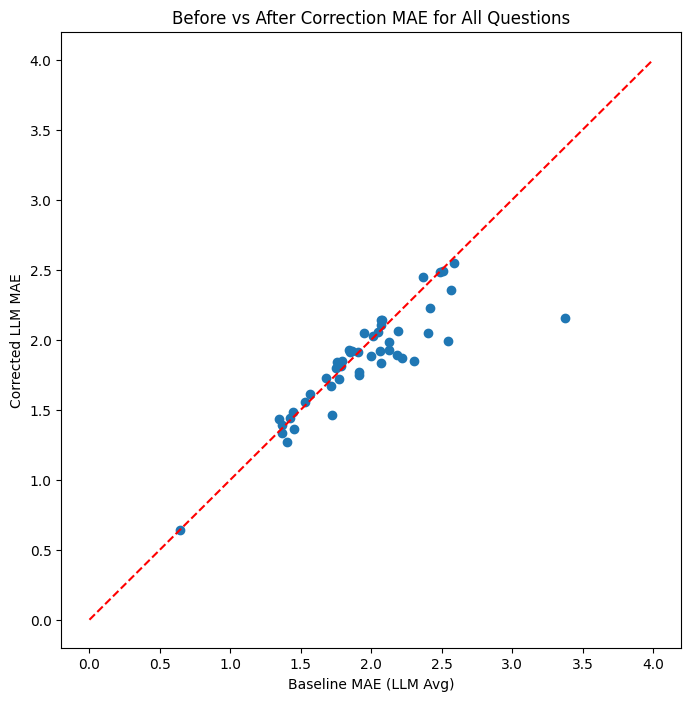

In [233]:
# plot before vs after correction maes for all questions
plt.figure(figsize=(8, 8))
plt.scatter(model_summary_df['Baseline_MAE'], model_summary_df['CV_MAE'])
plt.plot([0, 4], [0, 4], 'r--')
plt.xlabel('Baseline MAE (LLM Avg)')
plt.ylabel('Corrected LLM MAE')
plt.title('Before vs After Correction MAE for All Questions')

Text(0.5, 1.0, 'Distribution of Overall R² after Correction')

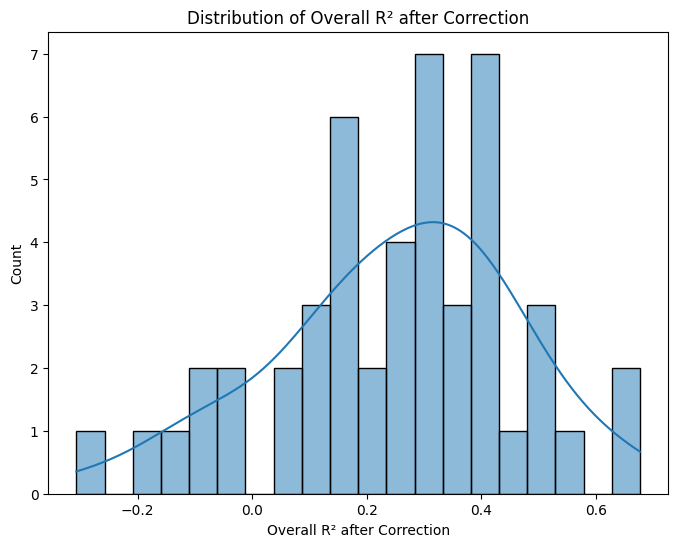

In [234]:
# plot r2 distribution
plt.figure(figsize=(8, 6))
sns.histplot(model_summary_df['Overall_R2'], bins=20, kde=True)
plt.xlabel('Overall R² after Correction')
plt.title('Distribution of Overall R² after Correction')

Text(0, 0.5, 'Wasserstein Distance between LLM and Human After Responses')

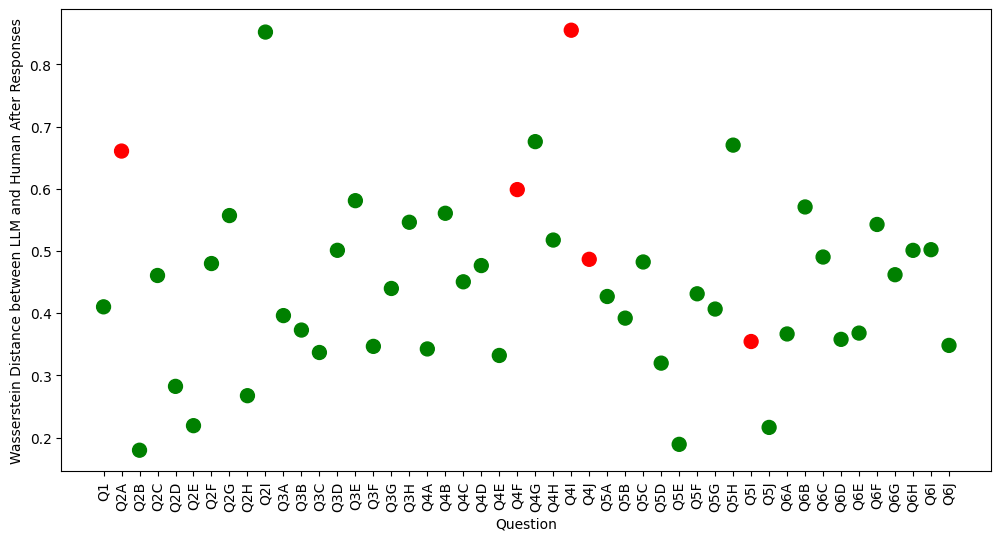

In [226]:
results = []
for question in questions:
    q_df = final_df[final_df['Question'] == question]
    human  = q_df['AfterNumber']

    llm = q_df['Corrected_LLM']

    ks_stat, ks_pval = ks_2samp(human, llm)
    w_dist = wasserstein_distance(human, llm)
    # choose shared bins, e.g. 0,1,2,...,10
    bins = np.arange(0, 11)  # or np.arange(0, 11+1) if using np.histogram

    # histograms -> counts per bin
    h_counts, _ = np.histogram(human, bins=bins, density=False)
    l_counts, _ = np.histogram(llm, bins=bins, density=False)

    # convert to probabilities
    p_h = h_counts / h_counts.sum()
    p_l = l_counts / l_counts.sum()

    js = jensenshannon(p_h, p_l)

    wc = stats.wilcoxon(human, llm)
    
    results.append({
        'question': question,
        'human_shift': human.mean(),
        'llm_mean_shift': llm.mean(),
        'ks_D': ks_stat,
        'ks_p': ks_pval,
        'wasserstein': w_dist,
        'js_mean': js,
        'wilcoxon_stat': wc.statistic,
        'wilcoxon_p': wc.pvalue
        
    })
results_df = pd.DataFrame(results)
# get significant questions
results_df['no_sig_diff'] = results_df['wilcoxon_p'] > 0.05
plt.figure(figsize=(12, 6))
plt.scatter(results_df['question'], results_df['wasserstein'], s=100, c=results_df['no_sig_diff'].map({True: 'green', False: 'red'}))
plt.xticks(rotation=90)
plt.xlabel('Question')
plt.ylabel('Wasserstein Distance between LLM and Human After Responses')

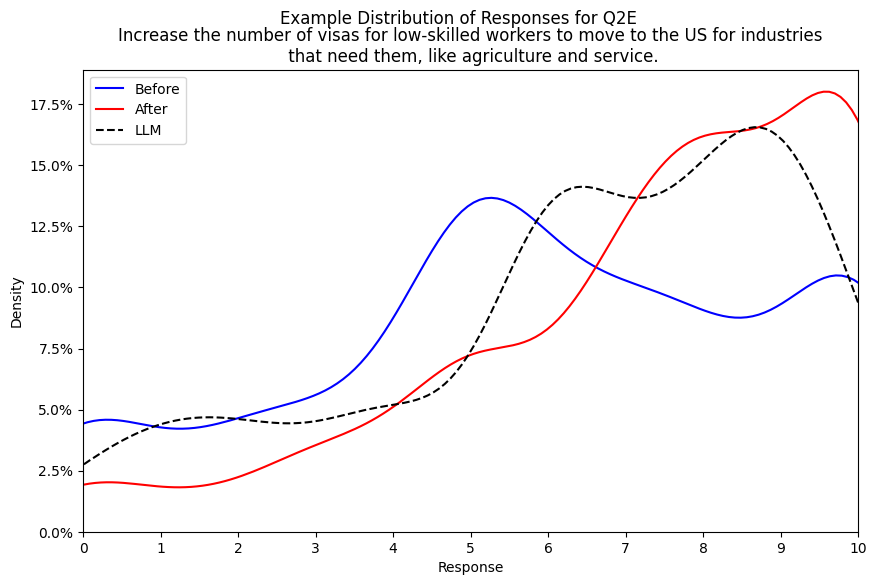

In [204]:
# plot before, after, llm, corrected llm for a question
question_to_plot = questions[5]  # change index to plot different questions
import matplotlib.ticker as mtick

qdf = final_df[final_df['Question'] == question_to_plot]
plt.figure(figsize=(10, 6))
ax = sns.kdeplot(qdf['BeforeNumber'], label='Before', color='blue')
sns.kdeplot(qdf['AfterNumber'], label='After', color='red')
sns.kdeplot(qdf['llm_avg'], label='LLM', color='black', linestyle='--')
#sns.kdeplot(qdf['Corrected_LLM'], label='Corrected LLM', color='orange')
plt.suptitle('Example Distribution of Responses for Q2E')
plt.title('Increase the number of visas for low-skilled workers to move to the US for industries\n that need them, like agriculture and service.')
plt.xlim(0,10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax = 1))
# change y ticks to percemtage
plt.xlabel('Response')
plt.ylabel('Density')
plt.xticks(range(0,11))
plt.legend()
plt.savefig('figures/example_distribution_Q2E_not_correct.pdf')

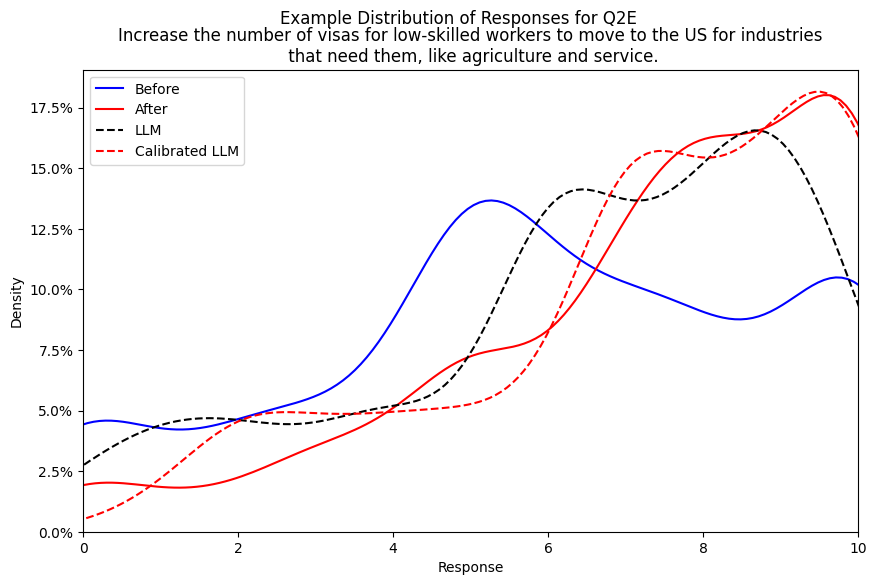

In [205]:
# plot before, after, llm, corrected llm for a question
question_to_plot = questions[5]  # change index to plot different questions
import matplotlib.ticker as mtick

qdf = final_df[final_df['Question'] == question_to_plot]
plt.figure(figsize=(10, 6))
ax = sns.kdeplot(qdf['BeforeNumber'], label='Before', color='blue')
sns.kdeplot(qdf['AfterNumber'], label='After', color='red')
sns.kdeplot(qdf['llm_avg'], label='LLM', color='black', linestyle='--')
sns.kdeplot(qdf['Corrected_LLM'], label='Calibrated LLM', color='red', linestyle='--')
plt.suptitle('Example Distribution of Responses for Q2E')
plt.title('Increase the number of visas for low-skilled workers to move to the US for industries\n that need them, like agriculture and service.')
plt.xlim(0,10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax = 1))
# change y ticks to percemtage
plt.xlabel('Response')
plt.ylabel('Density')
plt.legend()
plt.savefig('figures/example_distribution_Q2E_correct.pdf')

In [237]:
# join results to master df to get topics
master_with_results = results_df.merge(master_df, left_on='question', right_on='Question', how='left')
master_with_results[['Question','Topic','no_sig_diff']].drop_duplicates().groupby(['Topic','no_sig_diff']).count()

Question
Topic           no_sig_diff          
Climate Change  True                8
Democracy       True                1
Global Position True               10
Healthcare      False               1
                True                9
Immigration     False               1
                True                8
Taxes           False               3
                True                7

In [ ]:
questions_to_leave_out = results_df[results_df['no_sig_diff'] == False]['question'].tolist()
final_df_cleaned = final_df[~final_df['Question'].isin(questions_to_leave_out)]
final_df_cleaned.to_csv('final_df_corrected_cleaned.csv', index=False)

In [235]:
# checking AI1R statements
#master_df = pd.read_csv('clean_data/question_level_master_dataset.csv')
demrep = final_df[(final_df['PARTYBEFORE']=='Democrat') | (final_df['PARTYBEFORE']=='Republican')]
extreme_data = demrep.groupby(['Question','PARTYBEFORE','BeforeNumber'])['ID'].count().reset_index()
extreme_data = extreme_data.rename(columns={'ID':'Count'})
extreme_data.head()

# Criterion A:  At least 15% of respondents identifying with each party (Democrats AND Republicans) selected
# the most extreme position (0 or 10 on a 0-10 scale), with these extremes positioned at opposite poles.
extremeQuestionsA = []
for question in questions:
    extremeQuestion = {}
    for party in ['Democrat', 'Republican']:
        subset = extreme_data[(extreme_data['Question']==question) & (extreme_data['PARTYBEFORE']==party)]
        total = subset['Count'].sum()
        prop0 = subset[subset['BeforeNumber'] == 0]['Count'].sum() / total
        prop10 = subset[subset['BeforeNumber'] == 10]['Count'].sum() / total
        left = subset[subset['BeforeNumber'] < 5]['Count'].sum()
        right = subset[subset['BeforeNumber'] > 5]['Count'].sum()
        if prop0 >= 0.15 and left > right:
            extremeQuestion[party] = 0
        elif prop10 >= 0.15 and right > left:
            extremeQuestion[party] = 10
    # assuming only one side can be extreme per party
        
    if len(extremeQuestion) == 2 and extremeQuestion['Democrat'] != extremeQuestion['Republican']:
        extremeQuestionsA.append(question)

print(f"Number of extreme questions: {len(extremeQuestionsA)}")

Number of extreme questions: 27


In [236]:
# checking AI1R statements
#master_df = pd.read_csv('clean_data/question_level_master_dataset.csv')
demrep = final_df[(final_df['PARTYBEFORE']=='Democrat') | (final_df['PARTYBEFORE']=='Republican')]
extreme_data = demrep.groupby(['Question','PARTYBEFORE','Corrected_LLM'])['ID'].count().reset_index()
extreme_data = extreme_data.rename(columns={'ID':'Count'})
extreme_data.head()

# Criterion A:  At least 15% of respondents identifying with each party (Democrats AND Republicans) selected
# the most extreme position (0 or 10 on a 0-10 scale), with these extremes positioned at opposite poles.
extremeQuestionsA = []
for question in questions:
    extremeQuestion = {}
    for party in ['Democrat', 'Republican']:
        subset = extreme_data[(extreme_data['Question']==question) & (extreme_data['PARTYBEFORE']==party)]
        total = subset['Count'].sum()
        prop0 = subset[subset['Corrected_LLM'] == 0]['Count'].sum() / total
        prop10 = subset[subset['Corrected_LLM'] == 10]['Count'].sum() / total
        left = subset[subset['Corrected_LLM'] < 5]['Count'].sum()
        right = subset[subset['Corrected_LLM'] > 5]['Count'].sum()
        if prop0 >= 0.15 and left > right:
            extremeQuestion[party] = 0
        elif prop10 >= 0.15 and right > left:
            extremeQuestion[party] = 10
    # assuming only one side can be extreme per party
        
    if len(extremeQuestion) == 2 and extremeQuestion['Democrat'] != extremeQuestion['Republican']:
        extremeQuestionsA.append(question)

print(f"Number of extreme questions: {len(extremeQuestionsA)}")

Number of extreme questions: 0
